# QuickStart: デリーの気候データで学ぶ複数系列の時系列予測

- **作成者**: ImoZukushi
- **作成日**: 2026-09-26
- **目的**: `src/` 配下のモジュール（`util` / `feature_engineering` / `modeling`）を使い、
  時系列予測の一連の流れ（特徴量のパイプライン化 → 再帰的多段予測 → Optunaによるチューニング →
  SHAPによる解釈 → アンサンブル → テスト期間での評価）を1本のノートブックで体験する。
- **元スクリプト**: `scripts/quickstart_delhi_climate.py`（同じ処理をCLIで実行できる）

## このノートブックでやること

デリーの日次気候データ（`data/raw/DailyDelhiClimateTrain.csv` / `DailyDelhiClimateTest.csv`）の
3つの変数 `meantemp`（日平均気温）・`humidity`（湿度）・`meanpressure`（平均気圧）を、
**1つのモデル（グローバルモデル）で3系列まとめて** 再帰的に多段予測します。
モデルは LightGBM と XGBoost の2種類を作り、最後にアンサンブルします。

### グローバルモデルとは
変数ごとに別々のモデルを作るのではなく、3変数の履歴を縦に積んだ1つの学習データで1つのモデルを学習する方式です。
「どの変数を予測しているか」は系列ID（`variable` 列）を特徴量として渡すことでモデルに伝えます。
系列間で共通する季節パターンなどを共有して学習でき、1系列あたりのデータが少ない場合にも有利です。

### 再帰的多段予測とは
学習は「過去の実測値から作ったラグで1日先を予測する」モデルとして行い、予測時は
**予測値を次の日のラグとして使いながら1日ずつ進みます**。これにより、実測値が得られない数か月先まで予測できます。

### 目的変数の変換（365日の季節差分）
気温・湿度・気圧には年周期の強い季節性があります。GBDTは学習データの範囲の外へ外挿できないため、
このノートブックでは目的変数を **「前年同日との差」（365日の季節差分）** に変換して学習・再帰予測し、
予測値に前年同日の実測値を足して元の尺度に戻してから評価・出力します（`forecast.target_transform`）。
ラグ・移動平均の特徴量も、この差分系列から作られます。

### 処理の流れ
1. データ読み込みと整形（`date` と3変数以外の `wind_speed` はドロップ、横持ち → 縦持ち）
2. 実験設定の作成（`modeling.config.ExperimentConfig`。目的変数は365日の季節差分に変換）
3. モデルごとに Optuna探索 → 最良パラメータで学習 → SHAP → テスト期間の再帰予測（`run_experiment`）
4. 2モデルのアンサンブル（`run_ensemble`）
5. テスト期間の実測値と比べたMAE（変数別・全体）と、予測の比較図

### データについての前提
- 学習データの最終行（2017-01-01）はテストデータの初日と重なるため、テスト開始日以降の学習行は除外します
  （再帰予測は学習期間の直後から始める必要があるため）。
- テストデータには実測値が含まれますが、予測には使いません（予測時は日付と系列IDのみを渡し、答え合わせだけに使います）。
- 3変数は尺度が大きく異なります（気温 ≈ 25, 湿度 ≈ 60, 気圧 ≈ 1010）。全体のMAEはばらつきの大きい変数の影響を強く受けるため、変数別のMAEもあわせて確認します。
- `meanpressure` には物理的にありえない異常値が含まれます（学習データに 7679, -3, 310 hPa など9件、テストデータに 59 hPa が1件）。
  生データは変更せず、学習データでは欠損扱いにして前後の日から線形補間し、テストデータでは評価から除外します。
- 365日の季節差分では前年同日の値が必要なため、各系列の最初の365日（2013年）は学習に使えません
  （データやCVの分割からは除かず、モデルのfitからだけ除外されます）。
  そのため、最初の検証期間（2015-09〜）の学習に使えるのは2014年以降のデータになります。

## 1. ライブラリの読み込み

リポジトリの `src/` をimportできるよう、`pyproject.toml` のあるディレクトリ（リポジトリルート）を探して
`sys.path` に追加します。ノートブックをどのディレクトリから開いても動くようにするためです。

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import Image, display

# pyproject.toml を目印にリポジトリルートを探し、src/ をimportパスに追加する
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

# src/ 配下のモジュール（上でパスを追加した後にimportする必要がある）
from modeling.config import EnsembleConfig, ExperimentConfig  # noqa: E402
from modeling.ensemble import EnsembleResult, run_ensemble  # noqa: E402
from modeling.experiment import ExperimentResult, prepare_dataset, run_experiment  # noqa: E402
from modeling.metrics import get_metric  # noqa: E402
from modeling.tracking import MLflowTracker, NullTracker, Tracker  # noqa: E402
from util.csv_io import read_csv_auto  # noqa: E402
from util.paths import data_dir, ensure_parent_dir, outputs_dir  # noqa: E402
from util.plotting import add_caption, ensure_japanese_font  # noqa: E402

# polars の表示で列を省略しすぎないようにする
pl.Config.set_tbl_cols(12)

c:\Users\imo_z\SIGNATE\analytics_cup_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


polars.config.Config

## 2. 実行パラメータと定数

次のセルは papermill のパラメータセル（`parameters` タグ付き）です。
`uv run papermill notebook/001_quickstart_delhi_climate.ipynb out.ipynb -p N_TRIALS 5` のように上書きできます。

- `N_TRIALS`: モデルごとのOptuna試行回数（20試行で合計7〜15分程度。まず動作確認したい場合は小さくする）
- `USE_TRACKING`: MLflowに記録するか（記録した結果は `uv run mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db` で閲覧）
- `OUTPUT_ROOT`: 出力のルート（`None` なら `outputs/`）

In [6]:
N_TRIALS = 10
USE_TRACKING = True
OUTPUT_ROOT = None

In [8]:
# 出力のルート（papermill から文字列で渡された場合も Path に変換する）
ROOT = Path(OUTPUT_ROOT) if OUTPUT_ROOT is not None else outputs_dir()

# 入力ファイル（data/raw は読み取り専用として扱い、書き込まない）
TRAIN_PATH = data_dir() / "raw" / "DailyDelhiClimateTrain.csv"
TEST_PATH = data_dir() / "raw" / "DailyDelhiClimateTest.csv"

# 予測する3つの変数（それぞれが1つの系列になる）。wind_speed は使わない
TARGET_VARIABLES = ("meantemp", "humidity", "meanpressure")

# 縦持ちに変換した後の列名
TIME_COL = "date"  # 時刻列
SERIES_COL = "variable"  # 系列ID（どの変数の値か）
TARGET = "value"  # 目的変数（各変数の値）

# meanpressure として物理的にありうる範囲（hPa）。範囲外は測定・記録の誤りとみなす
PRESSURE_VALID_RANGE = (950.0, 1050.0)

# 図の軸ラベル用の日本語名と単位
VARIABLE_LABELS = {
    "meantemp": "日平均気温 (℃)",
    "humidity": "湿度 (%)",
    "meanpressure": "平均気圧 (hPa)",
}

MODELS = ("lightgbm", "xgboost")  # 比較するモデル（modeling.models の登録名）
MLFLOW_EXPERIMENT = "delhi_quickstart"  # MLflowで全runをまとめる実験名

# テスト期間の日数。再帰バックテストで評価するステップ数もこれに合わせ、
# 「CVで測る精度」と「本番（テスト期間）で必要な予測の長さ」を揃える
HORIZON = 114

# 目的変数の季節差分の周期（日次データの年周期）。前年同日との差を予測する
SEASONAL_PERIOD = 365

print(f"出力先: {ROOT}")
print(f"Optuna試行回数: {N_TRIALS} / MLflow記録: {USE_TRACKING}")

出力先: C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs
Optuna試行回数: 10 / MLflow記録: True


## 3. データの読み込みと整形

### 3.1 整形用の関数
- `to_long`: 横持ち（1行 = 1日, 列 = 変数）を縦持ち（1行 = 1日 × 1変数）に変換します。グローバルモデルでは3変数を「系列IDの異なる3本の時系列」として縦に積みます。
- `interpolate_invalid_pressure`: 学習データの気圧の異常値を欠損にし、前後の日の値から線形補間します。そのままだとラグ特徴量に異常値が入り、再帰予測が大きく乱れるためです。
- `is_valid_observation`: テスト期間の実測値のうち、評価に使える行（気圧の異常値以外）を判定します。

In [9]:
def to_long(frame: pl.DataFrame) -> pl.DataFrame:
    """横持ち（1行=1日, 列=変数）を縦持ち（1行=1日×1変数）に変換する。"""
    return (
        frame.unpivot(
            index=TIME_COL,
            on=list(TARGET_VARIABLES),
            variable_name=SERIES_COL,
            value_name=TARGET,
        )
        # 同じ日付の中では変数名順に並べる（行順を決めておくと結果が再現しやすい）
        .sort(TIME_COL, SERIES_COL)
    )


def pressure_is_valid() -> pl.Expr:
    """`meanpressure` 列が物理的にありうる範囲内かを表す式（欠損はFalse）。"""
    low, high = PRESSURE_VALID_RANGE
    return pl.col("meanpressure").is_between(low, high).fill_null(False)


def interpolate_invalid_pressure(frame: pl.DataFrame) -> pl.DataFrame:
    """学習データの `meanpressure` の異常値を欠損にし、前後の日の値から線形補間する。"""
    return frame.with_columns(
        # 範囲外の値を欠損（null）に置き換える
        pl.when(pressure_is_valid())
        .then(pl.col("meanpressure"))
        .otherwise(None)
        # 前後の有効な値を直線で結んで埋める（日付順に並んでいることが前提）
        .interpolate()
        # 先頭・末尾の欠損は直線補間できないので、隣の有効な値で埋める
        .forward_fill()
        .backward_fill()
        .alias("meanpressure")
    )


def is_valid_observation(truth: pl.DataFrame) -> np.ndarray:
    """縦持ちの実測値のうち、評価に使える行かどうか（`meanpressure` の異常値はFalse）。"""
    low, high = PRESSURE_VALID_RANGE
    is_pressure = pl.col(SERIES_COL) == "meanpressure"
    in_range = pl.col(TARGET).is_between(low, high)
    # 気圧以外の変数は常に有効、気圧は範囲内のときだけ有効
    return truth.select((~is_pressure | in_range).fill_null(False)).to_series().to_numpy()

### 3.2 読み込み

`util.csv_io.read_csv_auto` はエンコーディングの自動判定と日付列の自動パースを行います。
異常値の件数を補間前に確認しておきます。

In [10]:
# date と3つの目的変数だけを残す（wind_speed はここでドロップされる）
columns = [TIME_COL, *TARGET_VARIABLES]
train_wide = read_csv_auto(TRAIN_PATH).select(columns)
test_wide = read_csv_auto(TEST_PATH).select(columns)

# 補間前に、気圧の異常値の件数と例を確認する
for name, frame in (("学習", train_wide), ("テスト", test_wide)):
    outliers = frame.filter(~pressure_is_valid())
    examples = outliers["meanpressure"].head(5).to_list()
    print(f"{name}データの気圧の範囲外: {outliers.height}件 例: {examples}")

train_wide.head()

学習データの気圧の範囲外: 9件 例: [7679.333333333333, 938.0666666666667, 946.3125, 310.4375, 633.9]
テストデータの気圧の範囲外: 1件 例: [59.0]


date,meantemp,humidity,meanpressure
datetime[μs],f64,f64,f64
2013-01-01 00:00:00,10.0,84.5,1015.666667
2013-01-02 00:00:00,7.4,92.0,1017.8
2013-01-03 00:00:00,7.166667,87.0,1018.666667
2013-01-04 00:00:00,8.666667,71.333333,1017.166667
2013-01-05 00:00:00,6.0,86.833333,1016.5


In [11]:
# 学習データの最終日はテストデータの初日と重なっているため、
# テスト開始日以降の学習行を除外する（再帰予測は学習期間の直後から始めるため）
test_start = test_wide[TIME_COL].min()
train_wide = train_wide.filter(pl.col(TIME_COL) < test_start).sort(TIME_COL)

# 学習データの気圧の異常値は補間する（テストデータの異常値は評価時に除外する）
train_wide = interpolate_invalid_pressure(train_wide)

# 縦持ちに変換する
train = to_long(train_wide)
truth = to_long(test_wide)
# 予測対象には実測値の列を渡さない（テストの答えがモデルに漏れないようにする）
test = truth.select(TIME_COL, SERIES_COL)

print(
    f"学習: {train[TIME_COL].n_unique()}日 × {len(TARGET_VARIABLES)}変数 = {train.height}行"
    f"（{train[TIME_COL].min()}〜{train[TIME_COL].max()}）"
)
print(
    f"予測: {test[TIME_COL].n_unique()}日 × {len(TARGET_VARIABLES)}変数 = {test.height}行"
    f"（{test[TIME_COL].min()}〜{test[TIME_COL].max()}）"
)
train.head(6)

学習: 1461日 × 3変数 = 4383行（2013-01-01 00:00:00〜2016-12-31 00:00:00）
予測: 114日 × 3変数 = 342行（2017-01-01 00:00:00〜2017-04-24 00:00:00）


date,variable,value
datetime[μs],str,f64
2013-01-01 00:00:00,"""humidity""",84.5
2013-01-01 00:00:00,"""meanpressure""",1015.666667
2013-01-01 00:00:00,"""meantemp""",10.0
2013-01-02 00:00:00,"""humidity""",92.0
2013-01-02 00:00:00,"""meanpressure""",1017.8
2013-01-02 00:00:00,"""meantemp""",7.4


In [12]:
# 変数ごとの要約統計（尺度が大きく違うことを確認する）
train.group_by(SERIES_COL).agg(
    pl.col(TARGET).mean().alias("mean"),
    pl.col(TARGET).std().alias("std"),
    pl.col(TARGET).min().alias("min"),
    pl.col(TARGET).max().alias("max"),
).sort(SERIES_COL)

variable,mean,std,min,max
str,f64,f64,f64,f64
"""humidity""",60.744851,16.743928,13.428571,98.0
"""meanpressure""",1008.244547,7.437207,991.375,1023.0
"""meantemp""",25.506127,7.339416,6.0,38.714286


## 4. 実験設定の作成

YAMLファイル（`configs/experiments/*.yaml`）に書く場合と同じ内容を、Pythonのdictで組み立てて
`ExperimentConfig` で検証します。主な設定は次のとおりです。

| 項目 | 内容 |
|---|---|
| `features` | 外生変数の特徴量。sklearn Pipelineに入り、CVの各foldで学習期間のデータだけを使って fit される（リーク防止）。系列IDの数値化 → 日付から月・日 → 日付列の削除 |
| `forecast` | 目的変数の変換と特徴量。目的変数は365日の季節差分（前年同日との差）に変換し、その差分系列のラグ（1, 2, 3, 7, 14日）と前日までの移動平均（7, 30日）を系列ごとに作る。予測時は予測値から作り直され、最後に元の尺度へ戻される |
| `cv` | 日付のカットオフで3分割（`time_cutoff`）。各検証期間の先頭114日を、実測値を使わずに再帰予測して評価（再帰バックテスト） |
| `tuning` | Optunaの探索。目的関数は再帰バックテストのMAE |
| `explain` | SHAPによる解釈（各foldモデルをその検証期間のデータで説明） |

In [13]:
def make_experiment_config(model: str, n_trials: int) -> ExperimentConfig:
    """1モデル分の実験設定を作る。"""
    return ExperimentConfig.model_validate(
        {
            "name": f"delhi_{model}",
            # time_series タスクでは、時間順を無視したCV（kfold等）を指定すると設定エラーになる
            "task": "time_series",
            "data": {
                # 記録用（データはこのノートブックで読み込んで prepare_dataset に直接渡す）
                "train_path": str(TRAIN_PATH),
                "target": TARGET,
                # 時刻列を指定すると、学習データがこの列で昇順に並べ替えられる
                "time_col": TIME_COL,
            },
            # 外生変数の特徴量（sklearn Pipeline内で学習foldごとに適用）
            "features": [
                # 系列ID（文字列）を整数に変換し、モデルが変数を区別できるようにする
                {
                    "class": "feature_engineering.categorical.PolarsOrdinalEncoder",
                    "params": {"variables": [SERIES_COL]},
                },
                # 日付から月・日を取り出す（date_month, date_day 列が追加される）。
                # 未来の日付でも計算できるので、再帰予測の外生変数として使える
                {
                    "class": "feature_engineering.datetime_features.DatetimeFeaturesExtractor",
                    "params": {"variables": [TIME_COL], "components": ["month", "day"]},
                },
                # 日付そのもの（日時型）はモデルに渡せないため削除する
                {"class": "modeling.pipeline.DropColumns", "params": {"columns": [TIME_COL]}},
            ],
            # 複数系列が混在するデータでは、行番号ではなく日付で区切る time_cutoff を使う
            "cv": {
                "method": "time_cutoff",
                "cutoffs": ["2015-09-01", "2016-01-01", "2016-05-01"],
            },
            "model": {
                "name": model,
                # 木の本数は多めにし、early stopping で打ち切る
                "params": {"n_estimators": 1000},
                "early_stopping_rounds": 50,
            },
            "metrics": ["mae"],
            # 再帰予測の設定（目的変数の変換と特徴量）
            "forecast": {
                "series_col": SERIES_COL,
                "lags": [1, 2, 3, 7, 14],  # 1〜3日前、1週間前、2週間前の値
                "rolling_windows": [7, 30],  # 前日までの7日・30日の平均
                "horizon": HORIZON,  # 各検証期間の先頭114日を評価する
                # 目的変数を「前年同日との差」（365日の季節差分）に変換して学習・予測する。
                # 年周期の季節性を差分で取り除くと、GBDTが苦手な外挿をしなくてよくなる。
                # 予測値は前年同日の実測値を足して元の尺度に戻してから評価・出力される。
                # ラグ・移動平均の特徴量も、この差分系列から作られる
                "target_transform": "seasonal_diff",
                "seasonal_period": SEASONAL_PERIOD,
            },
            "tuning": {"enabled": True, "n_trials": n_trials},
            "explain": {"enabled": True},
            "tracking": {"experiment_name": MLFLOW_EXPERIMENT},
        }
    )


def make_ensemble_config(member_dirs: dict[str, Path]) -> EnsembleConfig:
    """各実験の出力ディレクトリを構成要素とするアンサンブル設定を作る。"""
    return EnsembleConfig.model_validate(
        {
            "name": "delhi_blend",
            "task": "time_series",
            # 保存済みの予測ファイルを使うので、モデルの再学習は不要
            "members": [{"name": name, "path": str(path)} for name, path in member_dirs.items()],
            # OOF（再帰バックテストの予測）でMAEが最小になる重み（非負・合計1）を探索する
            "method": "weighted",
            "metrics": ["mae"],
            "tracking": {"experiment_name": MLFLOW_EXPERIMENT},
        }
    )


# 作成した設定の中身を、YAMLに書く場合と同じ形で確認する
example = make_experiment_config("lightgbm", N_TRIALS)
print(
    yaml.safe_dump(
        example.model_dump(mode="json", by_alias=True), allow_unicode=True, sort_keys=False
    )
)

name: delhi_lightgbm
task: time_series
data:
  train_path: C:\Users\imo_z\SIGNATE\analytics_cup_2026\data\raw\DailyDelhiClimateTrain.csv
  test_path: null
  target: value
  id_col: null
  group_col: null
  time_col: date
  feature_cols: null
  drop_cols: []
features:
- class: feature_engineering.categorical.PolarsOrdinalEncoder
  params:
    variables:
    - variable
- class: feature_engineering.datetime_features.DatetimeFeaturesExtractor
  params:
    variables:
    - date
    components:
    - month
    - day
- class: modeling.pipeline.DropColumns
  params:
    columns:
    - date
cv:
  method: time_cutoff
  n_splits: 5
  shuffle: true
  seed: 42
  gap: 0
  max_train_size: null
  test_size: null
  time_column: null
  cutoffs:
  - '2015-09-01'
  - '2016-01-01'
  - '2016-05-01'
  valid_end: null
model:
  name: lightgbm
  params:
    n_estimators: 1000
  early_stopping_rounds: 50
metrics:
- mae
test_prediction: fold_mean
seed: 42
tuning:
  enabled: true
  n_trials: 10
  timeout: null
  

## 5. モデルごとの学習（Optuna → 学習 → SHAP → テスト期間の予測）

`run_experiment` が次の処理をまとめて実行します。

1. Optunaで `N_TRIALS` 回探索（各試行の評価は再帰バックテストのMAE。studyは `outputs/optuna/` に保存され、再実行すると続きから探索）
2. 最良パラメータで再帰バックテスト（CVスコア・OOF予測・ステップ別スコアを保存）
3. SHAPで解釈（`shap/` に重要度・beeswarm図）
4. 学習期間全体を履歴として、テスト期間114日を再帰予測

表示される2つのMAEの差（再帰予測 − 1日先予測）が、予測値をラグに使うことによる誤差の蓄積分です。

In [14]:
results: dict[str, ExperimentResult] = {}
for model in MODELS:
    config = make_experiment_config(model, N_TRIALS)
    # MLflowに記録しない場合は、何もしない NullTracker を使う
    tracker: Tracker = MLflowTracker(MLFLOW_EXPERIMENT) if USE_TRACKING else NullTracker()
    print(f"=== {config.name}: Optuna {N_TRIALS}試行 → 学習・SHAP・テスト予測 ===")
    # prepare_dataset: 目的変数の特徴量（ラグ・移動平均）の付与とCV分割の計算
    # run_experiment: チューニング・CV学習・予測の保存・SHAP・MLflow記録をまとめて実行
    results[model] = run_experiment(
        config,
        prepare_dataset(config, train, test),
        tracker=tracker,
        output_root=ROOT / "experiments",
        optuna_dir=ROOT / "optuna",
    )
    cv = results[model].cv_result
    onestep = getattr(cv, "onestep_oof_scores", {}).get("mae", float("nan"))
    print(f"  CV MAE（再帰{HORIZON}日）={cv.oof_scores['mae']:.4f} / 参考: 1日先={onestep:.4f}")
    print(f"  出力: {results[model].output_dir}")

=== delhi_lightgbm: Optuna 10試行 → 学習・SHAP・テスト予測 ===
  CV MAE（再帰114日）=6.2584 / 参考: 1日先=3.7520
  出力: C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\experiments\delhi_lightgbm\20260927_180601_656448
=== delhi_xgboost: Optuna 10試行 → 学習・SHAP・テスト予測 ===
  CV MAE（再帰114日）=7.1070 / 参考: 1日先=3.7717
  出力: C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\experiments\delhi_xgboost\20260927_180907_939769


### 5.1 チューニング結果とステップ別の誤差

`tuning_result.best_params` が採用されたハイパーパラメータです。
`horizon_error.png` は「検証期間の何日先か」ごとのMAEで、先のステップほど誤差が大きくなりやすい傾向を確認できます。

=== lightgbm ===
最良のCV MAE: 6.2584
最良パラメータ: {'n_estimators': 1000, 'learning_rate': 0.20455226155820153, 'num_leaves': 246, 'min_child_samples': 74, 'subsample': 0.7817398426173525, 'subsample_freq': 1, 'colsample_bytree': 0.7590901457953203, 'reg_alpha': 6.024296549289552, 'reg_lambda': 1.4842836354238495e-07}


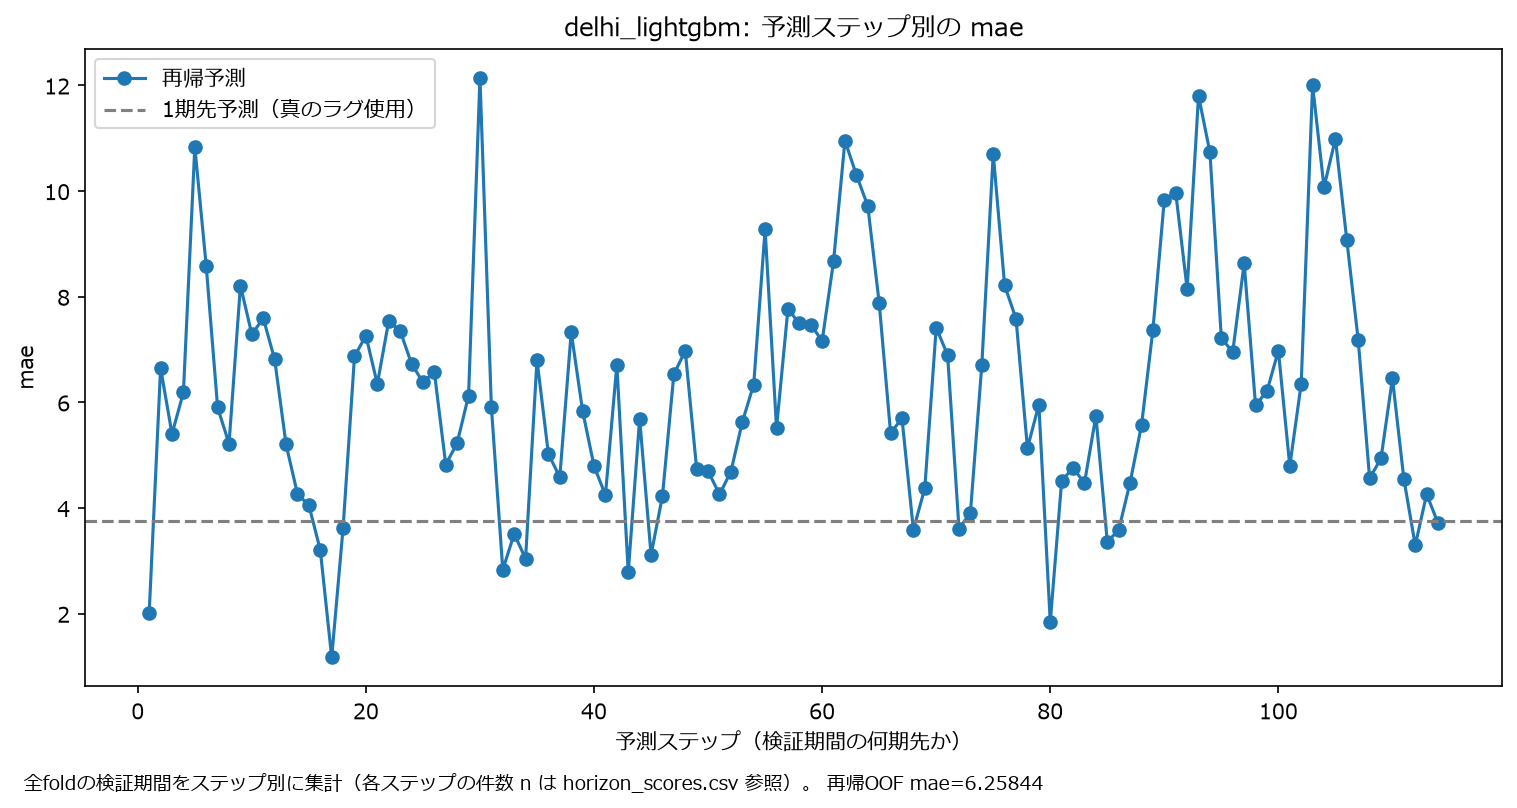

=== xgboost ===
最良のCV MAE: 7.1070
最良パラメータ: {'n_estimators': 1000, 'learning_rate': 0.013694986188093186, 'max_depth': 3, 'min_child_weight': 0.08638022189348338, 'subsample': 0.8046672524450882, 'colsample_bytree': 0.764101771659116, 'reg_alpha': 0.05685028474085979, 'reg_lambda': 0.9286829297457023}


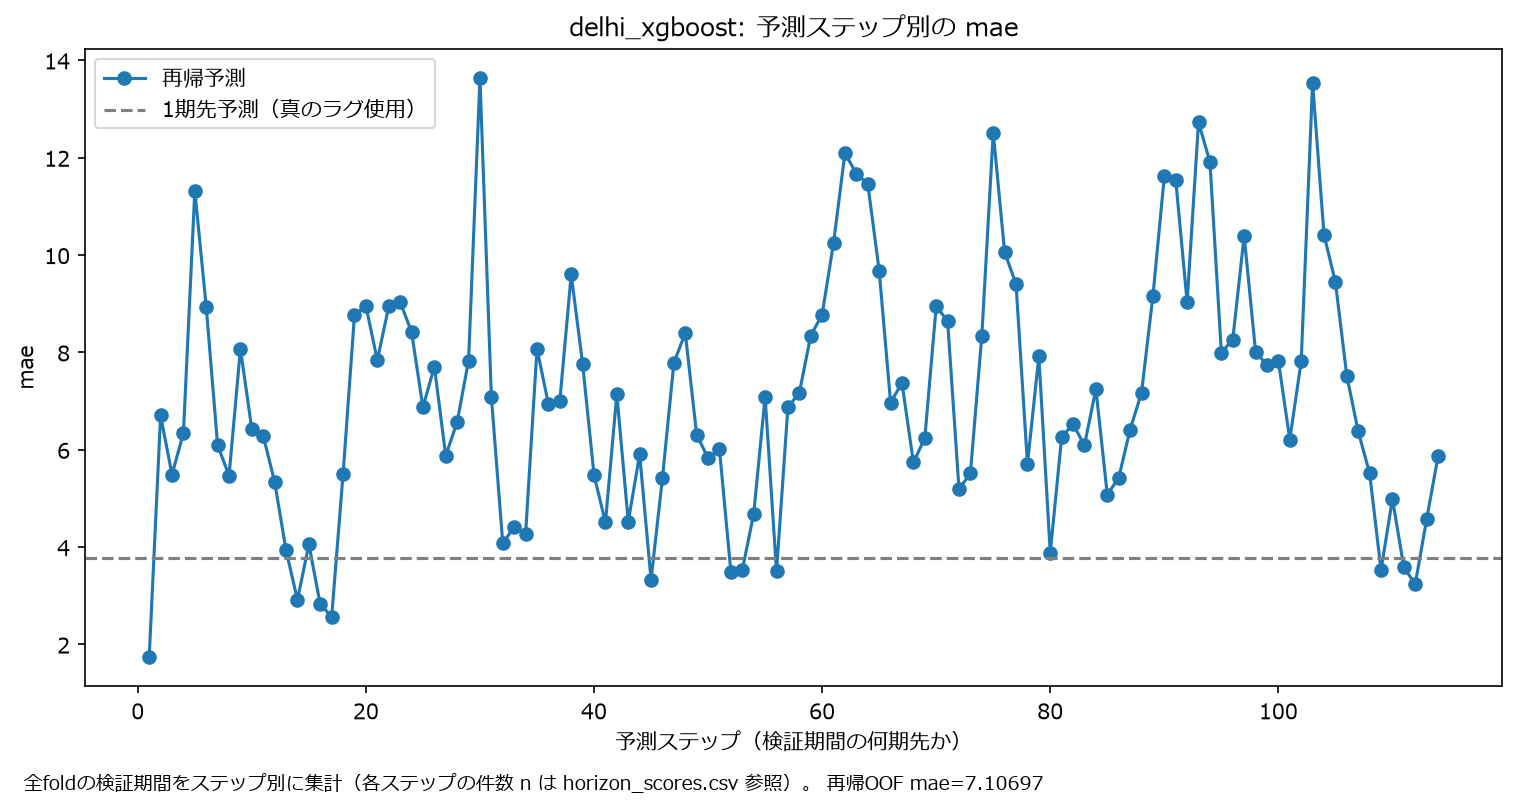

In [15]:
for model, result in results.items():
    print(f"=== {model} ===")
    if result.tuning_result is not None:
        print(f"最良のCV MAE: {result.tuning_result.best_value:.4f}")
        print(f"最良パラメータ: {result.tuning_result.best_params}")
    display(Image(filename=str(result.output_dir / "horizon_error.png"), width=800))

### 5.2 SHAPによる解釈

各foldモデルを、そのfoldの**検証期間のデータ**で説明した「OOF SHAP」です。
ラグ・移動平均（`value_lag_*`）や系列ID（`variable`）、月（`date_month`）がどれだけ予測に効いているかを確認します。

=== lightgbm ===


feature,mean_abs_shap
str,f64
"""value_lag_1""",4.144031
"""value_lag_1_ma_7""",0.578546
"""value_lag_14""",0.319885
"""value_lag_2""",0.253672
"""value_lag_1_ma_30""",0.195551
"""value_lag_7""",0.152307
"""value_lag_3""",0.088874
"""date_month""",0.08545
"""date_day""",0.069655


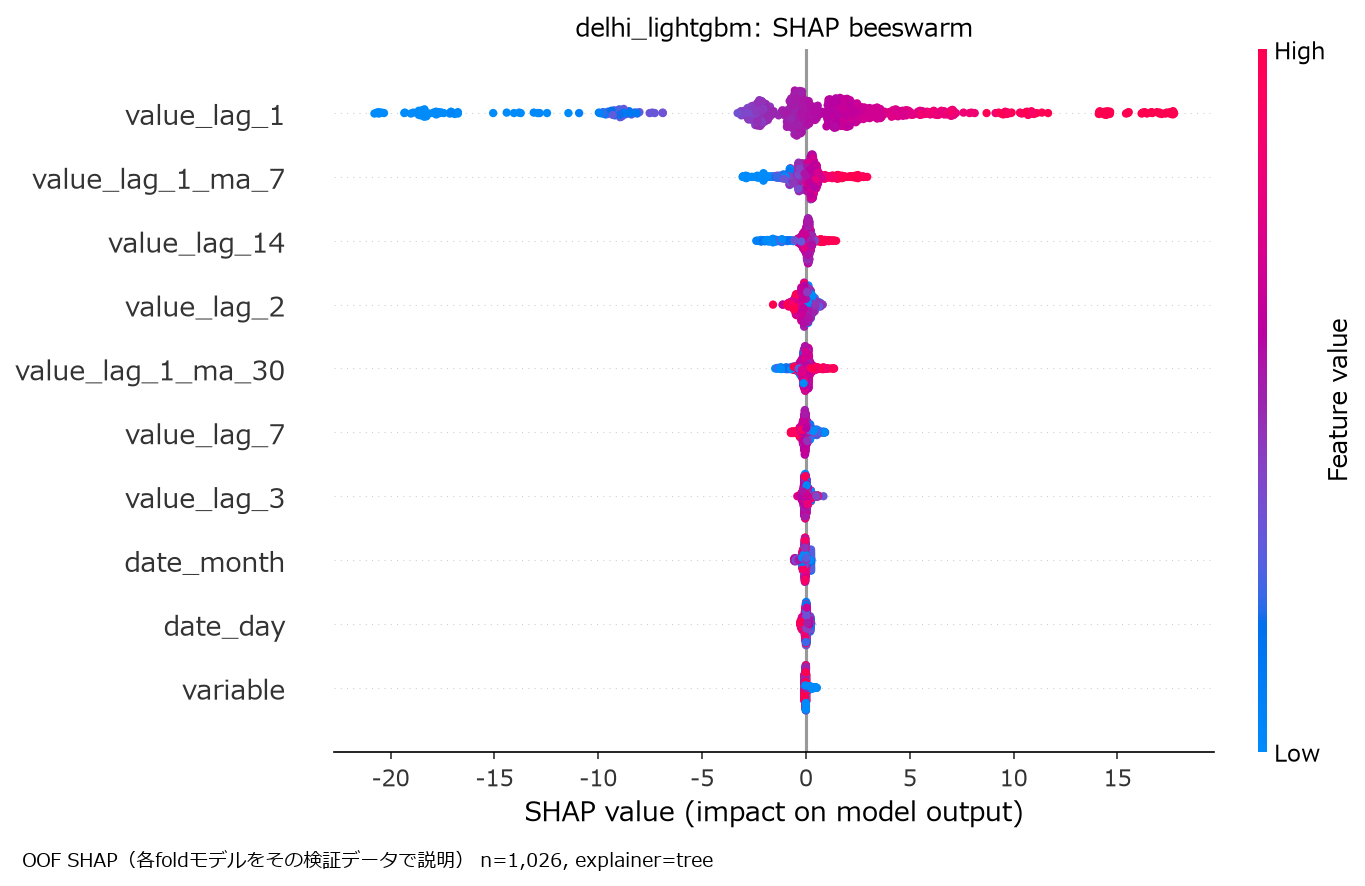

=== xgboost ===


feature,mean_abs_shap
str,f64
"""value_lag_1""",3.679922
"""value_lag_1_ma_7""",0.588844
"""value_lag_14""",0.274115
"""value_lag_1_ma_30""",0.212307
"""value_lag_2""",0.211412
"""value_lag_7""",0.209608
"""date_month""",0.12125
"""value_lag_3""",0.094823
"""date_day""",0.069057


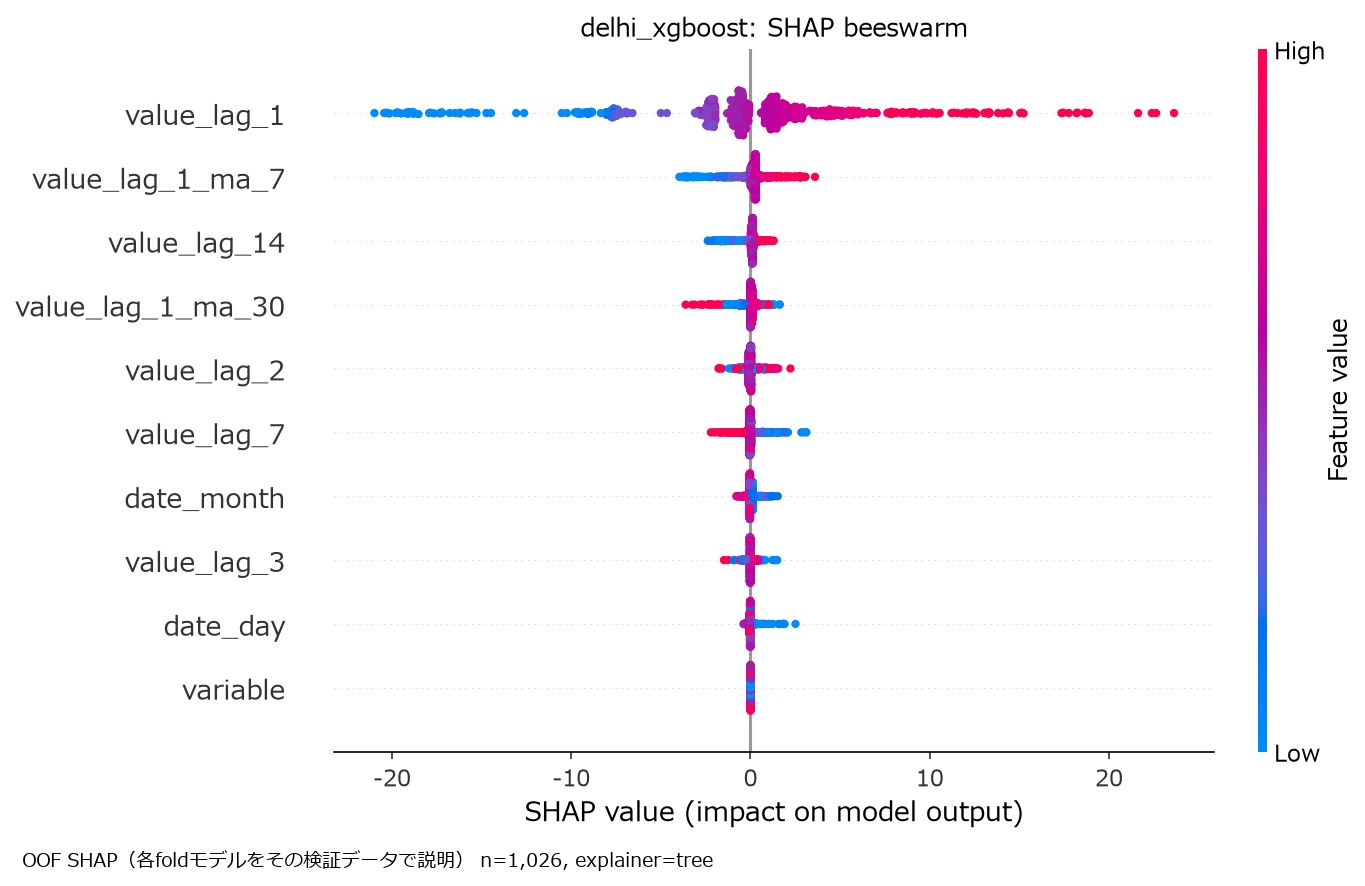

In [16]:
for model, result in results.items():
    shap_dir = result.output_dir / "shap"
    print(f"=== {model} ===")
    display(pl.read_csv(shap_dir / "shap_importance.csv").head(10))
    display(Image(filename=str(shap_dir / "shap_beeswarm.png"), width=800))

## 6. アンサンブル

各実験が保存したOOF予測（再帰バックテストの予測）から、MAEが最小になる重み（非負・合計1）を求め、
テスト期間の予測を加重平均します。モデルの再学習は不要です。

表の `ensemble_weighted` の値は、「あるfoldの予測には他のfoldで決めた重みを使う」方法で計算しています。
同じOOFで重みを決めて同じOOFで評価すると良く見えすぎるためです。

In [17]:
ensemble_tracker: Tracker = MLflowTracker(MLFLOW_EXPERIMENT) if USE_TRACKING else NullTracker()
ensemble: EnsembleResult = run_ensemble(
    make_ensemble_config({m: r.output_dir for m, r in results.items()}),
    tracker=ensemble_tracker,
    output_root=ROOT / "ensembles",
)
if ensemble.weights is not None:
    print("重み: " + ", ".join(f"{k}={v:.3f}" for k, v in ensemble.weights.items()))
ensemble.scores

重み: lightgbm=1.000, xgboost=0.000


model,mae
str,f64
"""lightgbm""",6.258443
"""xgboost""",7.10697
"""ensemble_weighted""",6.524122


## 7. テスト期間での評価

テスト期間の実測値と比べて、変数別・全体のMAEを計算します（気圧の異常値の行は除外）。
尺度が違うので、モデルの比較は同じ変数の中で行います。

In [18]:
def evaluate_on_test(truth: pl.DataFrame, predictions: dict[str, np.ndarray]) -> pl.DataFrame:
    """テスト期間の実測値と各モデルの予測から、変数別・全体のMAEを計算する。"""
    mae = get_metric("mae")
    y = truth[TARGET].to_numpy()
    series = truth[SERIES_COL].to_numpy()
    # 評価に使える行（気圧の異常値を除く）
    valid = is_valid_observation(truth)
    rows = []
    for model, pred in predictions.items():
        # 変数ごとのMAE
        for variable in TARGET_VARIABLES:
            mask = (series == variable) & valid
            rows.append(
                {
                    "model": model,
                    "variable": variable,
                    "n": int(mask.sum()),
                    # 評価できる行が無い変数は欠損（None）にする
                    "test_mae": mae(y[mask], pred[mask]) if mask.any() else None,
                }
            )
        # 3変数を通したMAE（アンサンブルの重み最適化と同じ基準）
        rows.append(
            {
                "model": model,
                "variable": "all",
                "n": int(valid.sum()),
                "test_mae": mae(y[valid], pred[valid]),
            }
        )
    return pl.DataFrame(rows)


# テスト期間の予測を集める（いずれも test / truth と同じ行順）
predictions: dict[str, np.ndarray] = {}
for model, result in results.items():
    assert result.cv_result.test_pred is not None
    predictions[model] = result.cv_result.test_pred
assert ensemble.test_pred is not None
predictions["ensemble"] = ensemble.test_pred

scores = evaluate_on_test(truth, predictions)
table_path = ensure_parent_dir(ROOT / "tables" / "delhi_quickstart__test_mae.csv")
scores.write_csv(table_path)

excluded = int((~is_valid_observation(truth)).sum())
print(f"気圧の範囲外 {PRESSURE_VALID_RANGE} の実測値 {excluded}件 は評価から除外")
print(f"表: {table_path}")
# 行: 変数、列: モデル の表にして表示する
scores.pivot(on="model", index="variable", values="test_mae")

気圧の範囲外 (950.0, 1050.0) の実測値 1件 は評価から除外
表: C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\tables\delhi_quickstart__test_mae.csv


variable,lightgbm,xgboost,ensemble
str,f64,f64,f64
"""meantemp""",2.434366,2.470924,2.434366
"""humidity""",9.087376,9.171973,9.087376
"""meanpressure""",2.87332,2.496235,2.87332
"""all""",4.803999,4.719545,4.803999


### 7.1 実測と予測の比較図

変数ごとに、テスト期間の実測値（黒）と各モデルの予測を重ねて表示します。

図: C:\Users\imo_z\SIGNATE\analytics_cup_2026\outputs\figures\delhi_quickstart__test_forecast.png


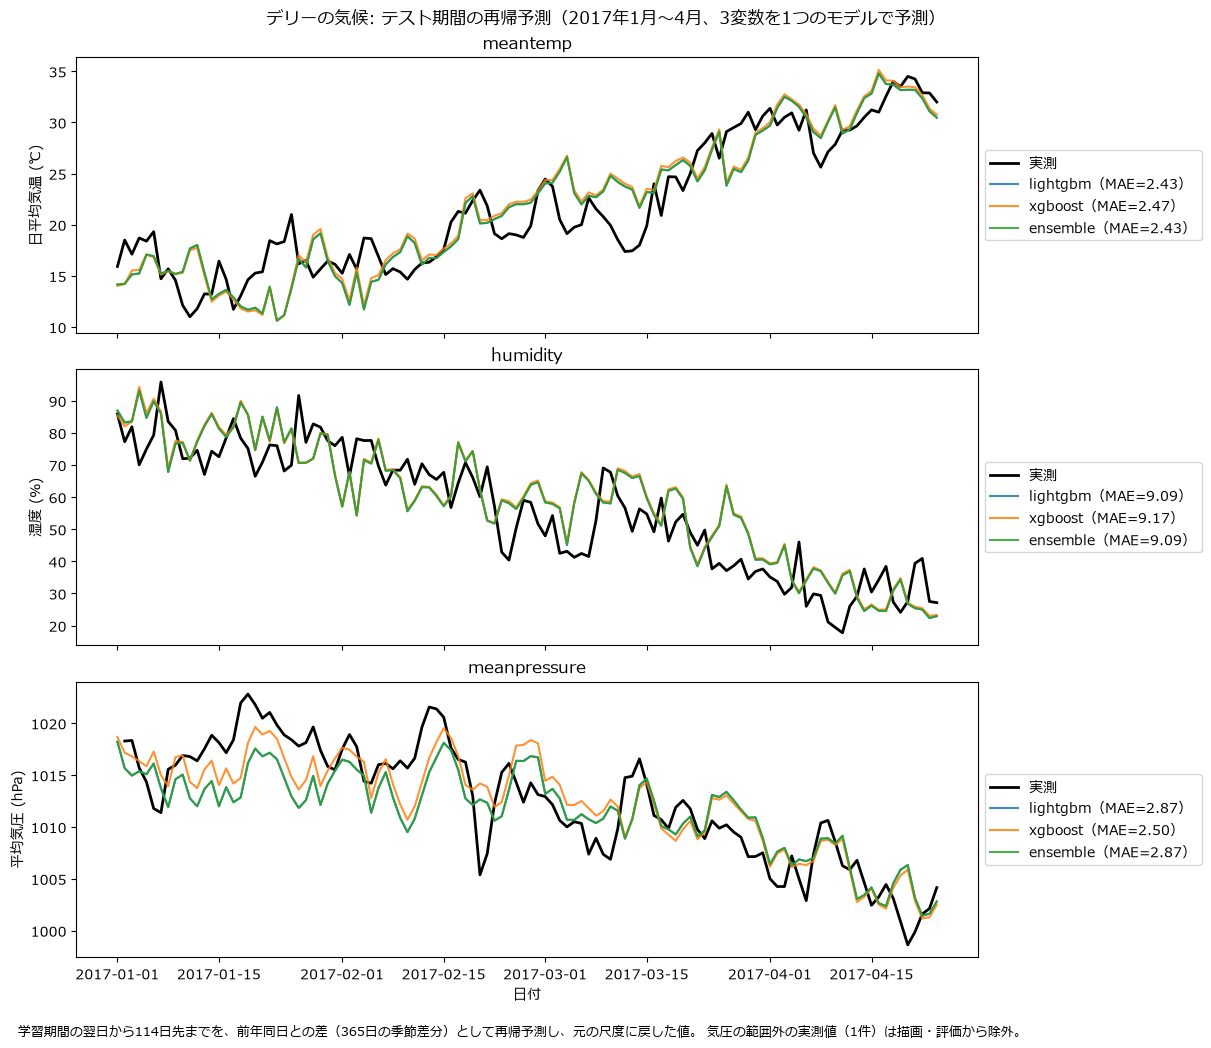

In [19]:
def plot_test_forecast(
    truth: pl.DataFrame, predictions: dict[str, np.ndarray], scores: pl.DataFrame
) -> plt.Figure:
    """変数ごとに、テスト期間の実測値と各モデルの予測を重ねて描く。"""
    ensure_japanese_font()
    fig, axes = plt.subplots(
        len(TARGET_VARIABLES), 1, figsize=(12, 10), sharex=True, constrained_layout=True
    )
    valid = is_valid_observation(truth)
    for ax, variable in zip(axes, TARGET_VARIABLES, strict=True):
        # この変数の行だけを取り出して描く（行順は日付順）
        mask = (truth[SERIES_COL] == variable).to_numpy()
        dates = truth.filter(pl.col(SERIES_COL) == variable)[TIME_COL].to_list()
        # 評価から除外した異常値はNaNにして線を途切れさせる（縦軸が異常値に引っ張られないように）
        actual = np.where(valid[mask], truth[TARGET].to_numpy()[mask], np.nan)
        ax.plot(dates, actual, color="black", linewidth=2, label="実測")
        for model, pred in predictions.items():
            model_mae = scores.filter(
                (pl.col("model") == model) & (pl.col("variable") == variable)
            )["test_mae"].item()
            ax.plot(dates, pred[mask], alpha=0.85, label=f"{model}（MAE={model_mae:.2f}）")
        ax.set_title(variable)
        ax.set_ylabel(VARIABLE_LABELS[variable])
        # 凡例が線に重ならないよう図の外側（右）に置く
        ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
    axes[-1].set_xlabel("日付")
    fig.suptitle("デリーの気候: テスト期間の再帰予測（2017年1月〜4月、3変数を1つのモデルで予測）")
    add_caption(
        fig,
        f"学習期間の翌日から{truth[TIME_COL].n_unique()}日先までを、前年同日との差"
        f"（{SEASONAL_PERIOD}日の季節差分）として再帰予測し、元の尺度に戻した値。"
        f" 気圧の範囲外の実測値（{int((~valid).sum())}件）は描画・評価から除外。",
    )
    return fig


fig = plot_test_forecast(truth, predictions, scores)
figure_path = ensure_parent_dir(ROOT / "figures" / "delhi_quickstart__test_forecast.png")
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
print(f"図: {figure_path}")
display(fig)
plt.close(fig)  # 二重表示を防ぎ、メモリを解放する

## 8. まとめと次のステップ

### このノートブックで確認したこと
- `ExperimentConfig` に `features`（外生変数のPipeline）と `forecast`（目的変数のラグ・移動平均）を書くだけで、
  リークのない再帰的多段予測・再帰バックテスト・Optuna・SHAP・MLflow記録がまとめて動く。
- 1日先予測のMAEに比べ、再帰予測のMAEは大きくなる。長期予測では誤差が蓄積するため、
  評価は再帰バックテストで行う必要がある。
- 3変数は尺度が違うため、全体のMAEは湿度・気圧の影響を強く受ける。モデルの比較は変数別のMAEで行う。
- `forecast.target_transform: seasonal_diff`（365日）を指定するだけで、前年同日との差を予測して
  元の尺度に戻す流れに切り替わる。年周期の季節性が強いこのデータでは、変換なしに比べて誤差が大きく下がる
  （LightGBM・チューニングなしの比較で、テスト期間の全体MAEが約11.1 → 約4.8）。

### 結果の読み方の注意
- 試行回数（`N_TRIALS`）が少ないと、選ばれたパラメータによっては予測がほぼ横ばいになることがある。
- CVは3foldのみのため、アンサンブルの重みやスコアはfoldによって大きく変わりうる。
- 気圧の異常値は補間・除外しているが、その閾値（950〜1050 hPa）は物理的な常識に基づく仮定である。

### 次のステップの例
- 変数ごとの尺度の違いをなくすため、目的変数を系列ごとに標準化してから学習する。
- 他の変数（気温・湿度など）のラグを互いの外生変数として使う（多変量の特徴量）。
- `forecast.horizon` やCVのカットオフを変え、予測の長さと精度の関係を確認する。
- `target_transform` を `log_seasonal_diff` や `diff` に変えて比較する（1日ごとの `diff` は再帰予測で誤差が蓄積しやすい）。
- `configs/experiments/*.yaml` に設定を書き出し、`scripts/run_experiment.py` からCLIで実行する。